In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import pickle

## Datos de ANSYS

In [2]:
def read_ANSYS(path):
    df = pd.read_csv(path, comment='#')
    legend = []
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('# ,'):
                legend = line.strip('# ,\n').split(',')
    legend = {duple.split(' - ')[0]: duple.split(' - ')[1] for duple in legend}
    if 'index' in df.columns:
        df.drop('index', axis=1, inplace=True)
    return df.rename(legend, axis=1)

In [3]:
ANSYS = {
    cells: {
        SoH: read_ANSYS(f'./Data_ANSYS/df_ANSYS/out{cells}_soh{SoH}.csv') for SoH in [45, 62, 82]
    } for cells in [25, 53]
}

In [4]:
ANSYS[25][62].head()

,Name,R,x1,y1,nx,ny,dx,dy,L,H,...,Tf02 [K],Tf03 [K],Tf04 [K],Vf01 [m s^-1],Vf02 [m s^-1],Vf03 [m s^-1],Vf04 [m s^-1],Tc01 [K],Tc02 [K],Tc03 [K]
0,DP 0,9,25,18.000,4,4,36.0,36.000,158.0,144.000,...,293.788,294.169,294.847,0.218611,0.205938,0.201033,0.207854,294.508,295.002,295.418
1,DP 1,9,25,14.400,4,4,36.0,28.800,158.0,115.200,...,297.066,304.262,311.716,0.170193,0.169231,0.169370,0.175799,311.010,309.195,315.685
2,DP 2,9,25,15.600,4,4,37.0,31.200,161.0,124.800,...,314.748,330.098,346.464,0.156934,0.159568,0.156907,0.168071,351.511,343.397,357.083
3,DP 3,9,25,17.004,4,4,36.0,34.008,158.0,136.032,...,288.789,291.427,294.501,0.139578,0.137894,0.134650,0.144140,296.642,295.196,297.382
4,DP 4,9,25,15.270,4,4,40.0,30.540,170.0,122.160,...,287.203,289.276,291.309,0.184719,0.179285,0.174622,0.188627,293.149,291.853,293.497


In [30]:
print(len(ANSYS[25][62].columns))

42


In [34]:
print(ANSYS[25][62][list(ANSYS[25][62].columns[: 21])].head())
print(ANSYS[25][62][list(ANSYS[25][62].columns[21: ])].head())

   Name  R  x1      y1  nx  ny    dx      dy      L        H  ...  \
0  DP 0  9  25  18.000   4   4  36.0  36.000  158.0  144.000  ...   
1  DP 1  9  25  14.400   4   4  36.0  28.800  158.0  115.200  ...   
2  DP 2  9  25  15.600   4   4  37.0  31.200  161.0  124.800  ...   
3  DP 3  9  25  17.004   4   4  36.0  34.008  158.0  136.032  ...   
4  DP 4  9  25  15.270   4   4  40.0  30.540  170.0  122.160  ...   

   q2 [W m^-3]  q3 [W m^-3]  q4 [W m^-3]  q5 [W m^-3]  q6 [W m^-3]  \
0    4235.0000    4235.0000    4235.0000    4235.0000    4235.0000   
1   74909.5944   37454.7972   37454.7972   37454.7972   37454.7972   
2  178916.3040   89458.1520   89458.1520   89458.1520   89458.1520   
3   34823.6751   17411.8375   17411.8375   17411.8375   17411.8375   
4   26156.4493   13078.2246   13078.2246   13078.2246   13078.2246   

   q7 [W m^-3]  mass_in [kg s^-1]  T_amb [K]  postx1  postr  
0    4235.0000           0.021600     293.15   0.025  0.009  
1   37454.7972           0.010296     28

In [5]:
print('ANSYS =', ANSYS[25][45].shape[0])
print('CDRAG =', pd.read_csv('./Data_Desgaste/df_cdrag_25_82.csv').shape[0])

ANSYS = 1396
CDRAG = 4500


In [6]:
print(ANSYS[25][82][ANSYS[25][82]['mass_in [kg s^-1]'] == 0.01029601][['dy', 'Vf01 [m s^-1]', 'Vf02 [m s^-1]',
                                                                 'Vf03 [m s^-1]', 'Vf04 [m s^-1]']])

         dy  Vf01 [m s^-1]  Vf02 [m s^-1]  Vf03 [m s^-1]  Vf04 [m s^-1]
1     28.80       0.170984       0.169910       0.169234       0.179138
2     31.20       0.155539       0.156066       0.155196       0.164607
151   47.00       0.132417       0.090529       0.052420       0.076387
152   43.78       0.150337       0.164728       0.070994       0.042568
261   43.66       0.136907       0.104318       0.059214       0.064285
262   35.40       0.164894       0.141768       0.100074       0.118018
399   40.66       0.091750       0.090796       0.087933       0.093427
400   45.08       0.075946       0.075539       0.072417       0.077436
413   59.00       0.090905       0.087849       0.043529       0.027968
452   46.46       0.143314       0.161153       0.058001       0.031579
501   28.80       0.169338       0.166630       0.170147       0.178738
502   31.20       0.154294       0.154784       0.154646       0.164729
651   47.00       0.135939       0.106503       0.053011       0

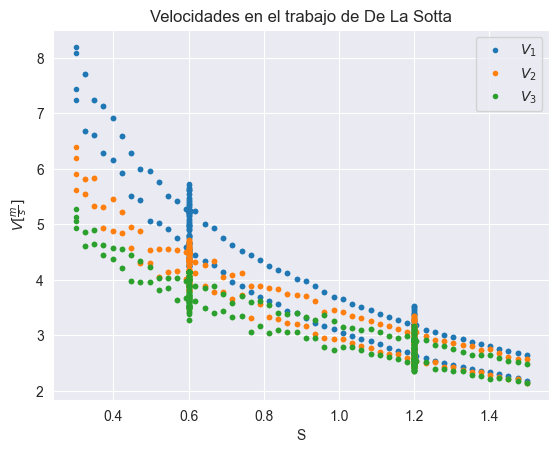

In [7]:
csv_sotta = read_ANSYS('./LIB_SR/DATA_ANSYS/entradas_1_25_celdas.csv')
df = csv_sotta[['massflow [kg s^-1]', 'K', 'V01 [m s^-1]', 'V02 [m s^-1]', 'V03 [m s^-1]', 'V04 [m s^-1]']][
    csv_sotta['massflow [kg s^-1]'] == csv_sotta['massflow [kg s^-1]'].iloc[0]
]

plt.plot(df['K'], df['V01 [m s^-1]'], '.', label=r'$V_1$')
plt.xlabel('S')
plt.ylabel(r'$V [\frac{m}{s}]$')

plt.plot(df['K'], df['V02 [m s^-1]'], '.', label=r'$V_2$')
plt.plot(df['K'], df['V03 [m s^-1]'], '.', label=r'$V_3$')

plt.title('Velocidades en el trabajo de De La Sotta')
plt.legend()

plt.show()

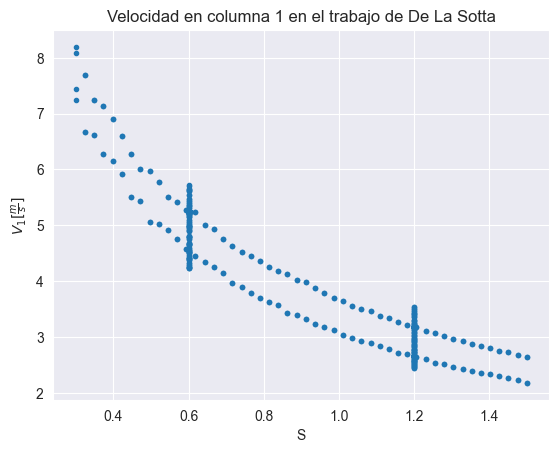

In [8]:
plt.title('Velocidad en columna 1 en el trabajo de De La Sotta')
plt.plot(df['K'], df['V01 [m s^-1]'], '.')
plt.xlabel('S')
plt.ylabel(r'$V_1 [\frac{m}{s}]$')
plt.show()

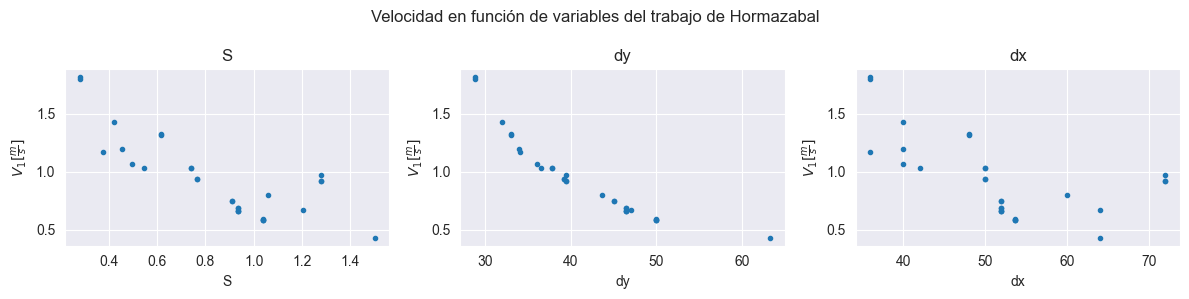

0.10590014


In [9]:
df2 = ANSYS[25][82][ANSYS[25][82]['mass_in [kg s^-1]'] == ANSYS[25][82]['mass_in [kg s^-1]'].iloc[500]][
    ['dx', 'dy', 'R', 'Vf01 [m s^-1]', 'Vf02 [m s^-1]', 'Vf03 [m s^-1]', 'Vf04 [m s^-1]',
     'Tf01 [K]', 'Tf02 [K]', 'L', 'q1 [W m^-3]']]
S = np.sqrt((df2['dy'] / 2)**2 + (df2['dx'] / 2)**2) / (2 * df2['R']) - 1

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(S, df2['Vf01 [m s^-1]'], '.')
ax[0].set_xlabel('S')
ax[0].set_ylabel(r'$V_1 [\frac{m}{s}]$')
ax[0].set_title('S')

ax[1].plot(df2['dy'], df2['Vf01 [m s^-1]'], '.')
ax[1].set_xlabel('dy')
ax[1].set_ylabel(r'$V_1 [\frac{m}{s}]$')
ax[1].set_title('dy')

ax[2].plot(df2['dx'], df2['Vf01 [m s^-1]'], '.')
ax[2].set_xlabel('dx')
ax[2].set_ylabel(r'$V_1 [\frac{m}{s}]$')
ax[2].set_title('dx')

fig.suptitle('Velocidad en función de variables del trabajo de Hormazabal')
plt.tight_layout()
plt.show()
print(ANSYS[25][82]['mass_in [kg s^-1]'].iloc[500])

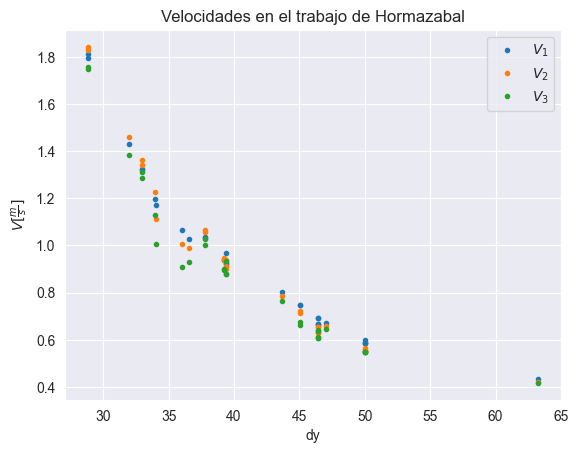

In [10]:
plt.plot(df2['dy'], df2['Vf01 [m s^-1]'], '.', label=r'$V_1$')
plt.xlabel('dy')
plt.ylabel(r'$V [\frac{m}{s}]$')

plt.plot(df2['dy'], df2['Vf02 [m s^-1]'], '.', label=r'$V_2$')
plt.plot(df2['dy'], df2['Vf03 [m s^-1]'], '.', label=r'$V_3$')

plt.title('Velocidades en el trabajo de Hormazabal')
plt.legend()

plt.show()

## Datos por coeficiente

In [127]:
all_dates = []

def get_SoH(row):
    r_eol = 0.12
    r_new = 0.032

    heats = []
    for c in list(row.index):
        if not pd.isna(row[c]) and c[0] == 'q':
            heats.append(row[c])
    heats = np.array(heats)
    arg_maxs = np.where(heats == heats.max())[0]
    if len(arg_maxs) == 1 and arg_maxs[0] not in all_dates:
        all_dates.append(arg_maxs[0])

    if row['colIndex'] - 1 in arg_maxs:
        r = (heats.max() / heats.min()) * r_new
        row['SoH'] = (r_eol - r) / (r_eol - r_new)
    else:
        row['SoH'] = 1.0
    return row

def read_COEF(absolute_path, coef, cells=(25, 53), sohs=(45, 63, 82)):
    absolute_path = absolute_path if absolute_path.endswith('/') else absolute_path + '/'
    dataframes = []
    for cell in cells:
        for soh in sohs:
            try:
                df = pd.read_csv(absolute_path + f'df_{coef}_{cell}_{soh}.csv')
            except FileNotFoundError:
                df1 = pd.read_csv(absolute_path + f'df_{coef}_{cell}_{soh}_v1.csv')
                df2 = pd.read_csv(absolute_path + f'df_{coef}_{cell}_{soh}_v2.csv')
                df = pd.concat([df1, df2])
            if 'index' in df.columns:
                df.drop('index', axis=1, inplace=True)
            df['n_cells'] = cell
            dataframes.append(df)

    return pd.concat(dataframes).apply(get_SoH, axis=1)

In [118]:
cdrag = read_COEF('./Data_Desgaste/', coef='cdrag')
cdrag.head()

,dx,dy,F_in,T_in,separation,q2,q4,q6,Desgaste,Rem,Dfn,colIndex,cdrag,n_cells,q8,q10,q12,q14,SoH
0,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,213.876319,1.022843,1,1.781540,25,NaN,NaN,NaN,NaN,0.454545
1,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,213.876319,0.982196,2,1.803549,25,NaN,NaN,NaN,NaN,1.000000
2,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,195.944895,0.958404,3,1.921602,25,NaN,NaN,NaN,NaN,1.000000
3,0.037,0.0312,0.010296,10.0,0.344410,223645.380000,89458.1520,89458.1520,Inicio,190.445681,1.002264,1,1.984263,25,NaN,NaN,NaN,NaN,0.454545
4,0.037,0.0312,0.010296,10.0,0.344410,223645.380000,89458.1520,89458.1520,Inicio,190.445681,0.935270,2,1.745809,25,NaN,NaN,NaN,NaN,1.000000


In [119]:
print(all_dates)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6)]


In [12]:
nu = read_COEF('./Data_Desgaste/', coef='n')
nu.head()

,dx,dy,F_in,T_in,separation,q2,q4,q6,Desgaste,Rem,prandtl,colIndex,nusselt,n_cells,q8,q10,q12,q14,SoH
0,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,213.876319,0.709845,1,12.207603,25,NaN,NaN,NaN,NaN,0.454545
1,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,213.876319,0.707115,2,13.360676,25,NaN,NaN,NaN,NaN,1.000000
2,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,195.944895,0.705911,3,14.863646,25,NaN,NaN,NaN,NaN,1.000000
3,0.037,0.0312,0.010296,10.0,0.344410,223645.380000,89458.1520,89458.1520,Inicio,190.445681,0.708510,1,11.385880,25,NaN,NaN,NaN,NaN,0.454545
4,0.037,0.0312,0.010296,10.0,0.344410,223645.380000,89458.1520,89458.1520,Inicio,190.445681,0.704177,2,13.068919,25,NaN,NaN,NaN,NaN,1.000000


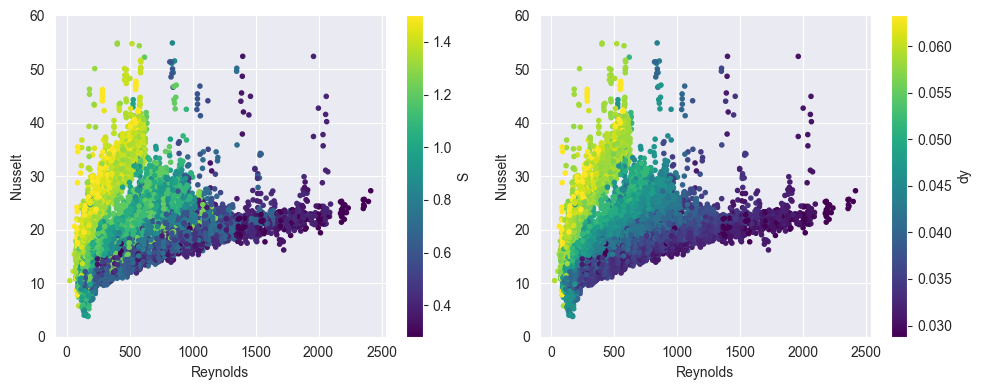

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df = nu[(nu['nusselt'] > 0) & (nu['nusselt'] < 55) & (nu['n_cells'] == 25)]

sc0 = ax[0].scatter(df['Rem'], df['nusselt'], marker='.', c=df['separation'], cmap='viridis')
fig.colorbar(sc0, ax=ax[0], label='S')
ax[0].set_ylim([0, 60])
ax[0].set_xlabel("Reynolds")
ax[0].set_ylabel("Nusselt")

sc1 = ax[1].scatter(df['Rem'], df['nusselt'], marker='.', c=df['dy'], cmap='viridis')
fig.colorbar(sc1, ax=ax[1], label='dy')
ax[1].set_ylim([0, 60])
ax[1].set_xlabel("Reynolds")
ax[1].set_ylabel("Nusselt")

plt.tight_layout()
plt.show()

In [4]:
from CoolProp.CoolProp import PropsSI

def get_SoH(row):
    r_eol = 0.12
    r_new = 0.032

    heats = []
    for c in list(row.index):
        if not pd.isna(row[c]) and c[0] == 'q':
            heats.append(row[c])
    heats = np.array(heats)
    arg_maxs = np.where(heats == heats.max())[0]
    if len(arg_maxs) == 1 and arg_maxs[0] not in all_dates:
        all_dates.append(arg_maxs[0])

    if row['colIndex'] - 1 in arg_maxs:
        r = (heats.max() / heats.min()) * r_new
        row['SoH'] = (r_eol - r) / (r_eol - r_new)
    else:
        row['SoH'] = 1.0
    return row

def get_props(temperature, grades='K'):
    p_atm = 101325
    t = temperature - 273.15 if grades == 'C' else temperature

    rho_fun = np.vectorize(lambda T: PropsSI('D', 'T', T, 'P', p_atm, 'Air'))
    mu_fun  = np.vectorize(lambda T: PropsSI('V', 'T', T, 'P', p_atm, 'Air'))
    k_fun   = np.vectorize(lambda T: PropsSI('L', 'T', T, 'P', p_atm, 'Air'))

    return pd.DataFrame({
        'rho': rho_fun(t),
        'mu' : mu_fun(t),
        'k'  : k_fun(t),
    })

In [130]:
def get_nusselt(dataframe):
    df = dataframe.copy()
    Dc = 2 * df['R'] * 1e-3  # [mm] -> [m]
    Dh = 2 * (df['postdx'] * df['postdy']) / (df['postdx'] + df['postdy'])
    height = df['L'] * 1e-3
    surf = np.pi * Dc * height
    vol = height * np.pi * (Dc / 2) ** 2

    results = []

    for col in range(1, 4):  # colIndex = [1, 2, 3]

        # temperaturas
        tf_kelvin = (df[f"Tf0{col} [K]"] + df[f"Tf0{col + 1} [K]"]) / 2
        tf_celc = tf_kelvin - 273.15
        dT = df[f"Tc0{col} [K]"] - 273.15 - tf_celc  # en [C]

        # propiedades
        props = get_props(tf_kelvin, grades='K')
        rho, mu, k = props['rho'], props['mu'], props['k']
        v = df[f"Vf0{col} [m s^-1]"]  # velocidad
        re = (rho * v * Dh) / mu  # reynolds

        # calcular h y nu
        q = df[f"q{col * 2} [W m^-3]" ] * vol
        q_surf = q / surf
        h = q_surf / (dT + 1e-9)
        nu = (h * Dh) / k

        # --- 9. Ensamblar datos para esta columna ---
        df_temp = pd.DataFrame({
            'S': df['postdy'] / Dc,
            'colIndex': col,
            'Re': re,
            'Nu': nu,
            'q2': df[f"q2 [W m^-3]" ],
            'q4': df[f"q4 [W m^-3]" ],
            'q6': df[f"q6 [W m^-3]" ],
            'Pr':
        })

        results.append(df_temp)

    return pd.concat(results, ignore_index=True).apply(get_SoH, axis=1)

In [136]:
df_nu6 = get_nusselt(ANSYS[25][62])
df_nu4 = get_nusselt(ANSYS[25][45])
df_nu8 = get_nusselt(ANSYS[25][82])

df_nu6.head()

,S,colIndex,Re,Nu,q2,q4,q6,SoH
0,2.000000,1.0,519.368000,28.415627,4235.0000,4235.0000,4235.0000,1.000000
1,1.600000,1.0,362.906880,21.993230,74909.5944,37454.7972,37454.7972,0.636364
2,1.733333,1.0,330.429219,21.306198,178916.3040,89458.1520,89458.1520,0.636364
3,1.889333,1.0,336.193291,21.634095,34823.6751,17411.8375,17411.8375,0.636364
4,1.696667,1.0,443.082724,21.800271,26156.4493,13078.2246,13078.2246,0.636364


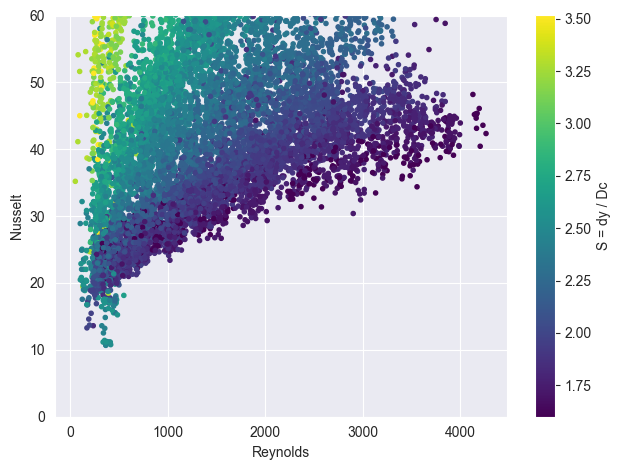

In [140]:
plt.scatter(df_nu6['Re'], df_nu6['Nu'], marker='.', c=df_nu6['S'], cmap='viridis')
plt.scatter(df_nu4['Re'], df_nu4['Nu'], marker='.', c=df_nu4['S'], cmap='viridis')
plt.scatter(df_nu8['Re'], df_nu8['Nu'], marker='.', c=df_nu8['S'], cmap='viridis')
plt.ylim([0, 60])
plt.colorbar(label='S = dy / Dc')
plt.ylabel("Nusselt")
plt.xlabel('Reynolds')
plt.tight_layout()
plt.show()

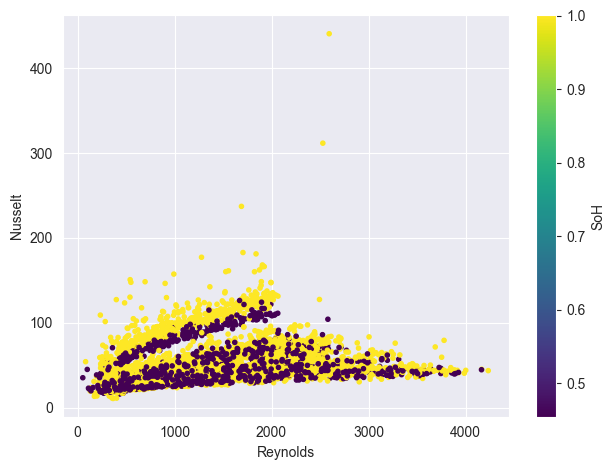

In [139]:
plt.scatter(df_nu4['Re'], df_nu4['Nu'], marker='.', c=df_nu4['SoH'], cmap='viridis')
plt.colorbar(label='SoH')
plt.ylabel("Nusselt")
plt.xlabel('Reynolds')
plt.tight_layout()
plt.show()

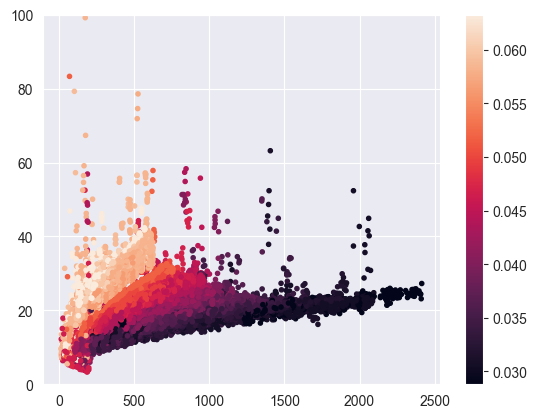

In [137]:
plt.scatter(nu['Rem'], nu['nusselt'], marker='.', c=nu['dy'], cmap)
plt.colorbar()
plt.ylim([0, 100])
plt.show()

In [9]:
ff = read_COEF('./Data_Desgaste/', coef='ff')
ff.head()

,dx,dy,F_in,T_in,separation,q2,q4,q6,Desgaste,Rem,Dfn,colIndex,frictionFactor,n_cells,q8,q10,q12,q14,SoH
0,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,213.876319,1.022843,1,2.939997,25,NaN,NaN,NaN,NaN,0.454545
1,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,213.876319,0.982196,2,3.023853,25,NaN,NaN,NaN,NaN,1.000000
2,0.036,0.0288,0.010296,10.0,0.280625,93636.992999,37454.7972,37454.7972,Inicio,195.944895,0.958404,3,3.288702,25,NaN,NaN,NaN,NaN,1.000000
3,0.037,0.0312,0.010296,10.0,0.344410,223645.380000,89458.1520,89458.1520,Inicio,190.445681,1.002264,1,2.777258,25,NaN,NaN,NaN,NaN,0.454545
4,0.037,0.0312,0.010296,10.0,0.344410,223645.380000,89458.1520,89458.1520,Inicio,190.445681,0.935270,2,2.293259,25,NaN,NaN,NaN,NaN,1.000000


In [10]:
print(cdrag['separation'].min(), cdrag['separation'].max())

0.2806248474865698 1.5000553080301793


In [11]:
cdrag_25 = cdrag[(cdrag['cdrag'] > 0) & (cdrag['cdrag'] < 6.5) & (cdrag['n_cells'] == 25)]
cdrag_53 = cdrag[(cdrag['cdrag'] > 0) & (cdrag['cdrag'] < 6.5) & (cdrag['n_cells'] == 53)]
print(len(cdrag_25), len(cdrag_53))

ff_25 = ff[(ff['frictionFactor'] > 0) & (ff['frictionFactor'] < 4) & (ff['n_cells'] == 25)]
ff_53 = ff[(ff['frictionFactor'] > 0) & (ff['frictionFactor'] < 4) & (ff['n_cells'] == 53)]
print(len(ff_25), len(ff_53))

nu_25 = nu[(nu['nusselt'] > 0) & (nu['nusselt'] < 55) & (nu['n_cells'] == 25)]
nu_53 = nu[(nu['nusselt'] > 0) & (nu['nusselt'] < 55) & (nu['n_cells'] == 53)]
print(len(nu_25), len(nu_53))

13432 31280
13391 31253
13477 31464


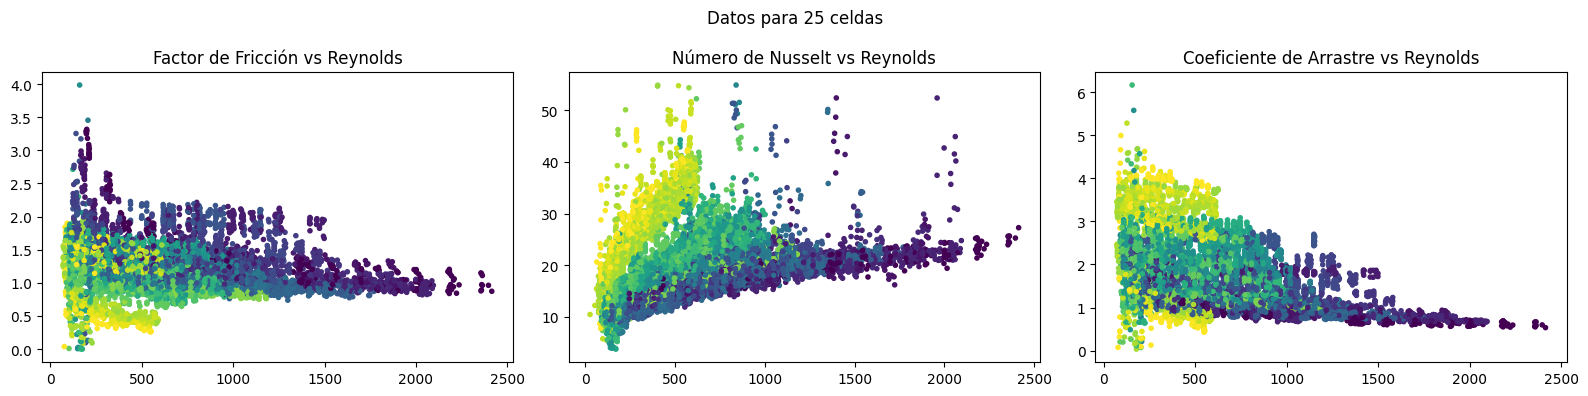

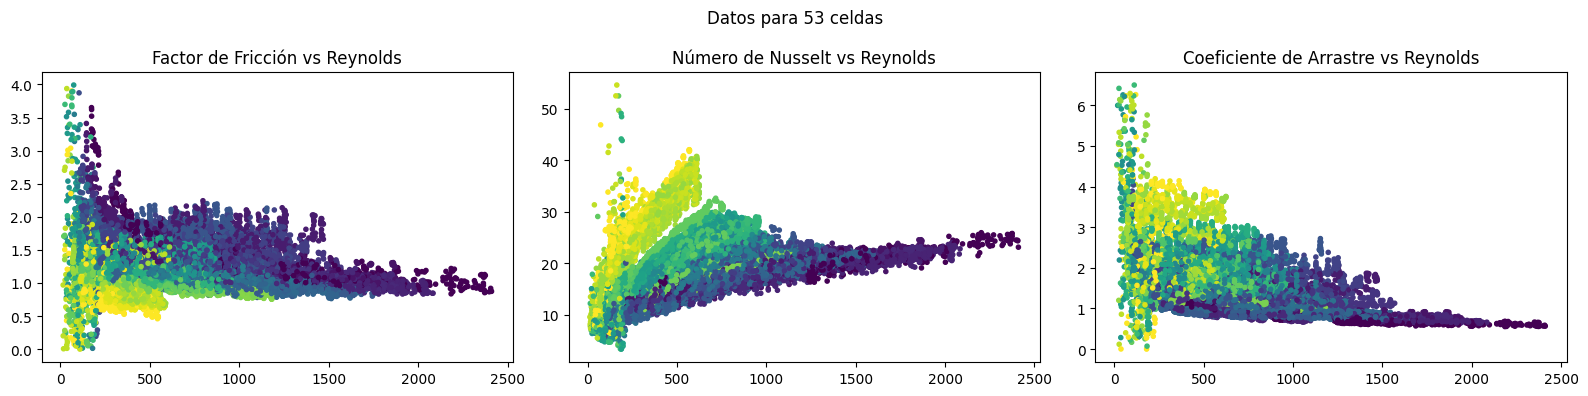

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ff_25['Rem'], ff_25['frictionFactor'], marker='.', c=ff_25['separation'])
axes[0].set_title('Factor de Fricción vs Reynolds')

axes[1].scatter(nu_25['Rem'], nu_25['nusselt'], marker='.', c=nu_25['separation'])
axes[1].set_title('Número de Nusselt vs Reynolds')

axes[2].scatter(cdrag_25['Rem'], cdrag_25['cdrag'], marker='.', c=cdrag_25['separation'])
axes[2].set_title('Coeficiente de Arrastre vs Reynolds')

fig.suptitle('Datos para 25 celdas')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ff_53['Rem'], ff_53['frictionFactor'], marker='.', c=ff_53['separation'])
axes[0].set_title('Factor de Fricción vs Reynolds')

axes[1].scatter(nu_53['Rem'], nu_53['nusselt'], marker='.', c=nu_53['separation'])
axes[1].set_title('Número de Nusselt vs Reynolds')

axes[2].scatter(cdrag_53['Rem'], cdrag_53['cdrag'], marker='.', c=cdrag_53['separation'])
axes[2].set_title('Coeficiente de Arrastre vs Reynolds')

fig.suptitle('Datos para 53 celdas')
plt.tight_layout()
plt.show()

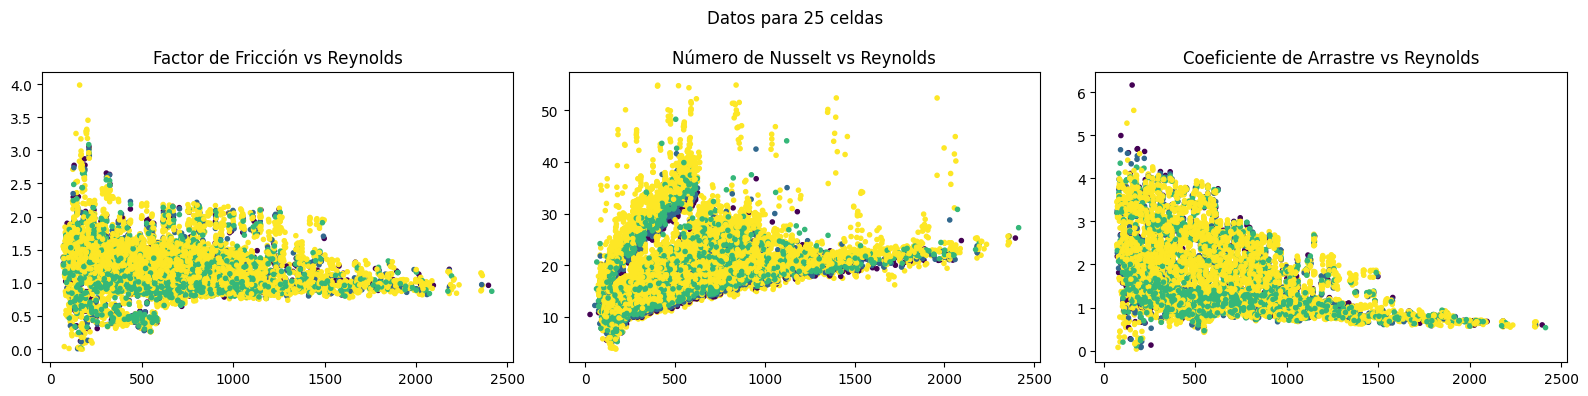

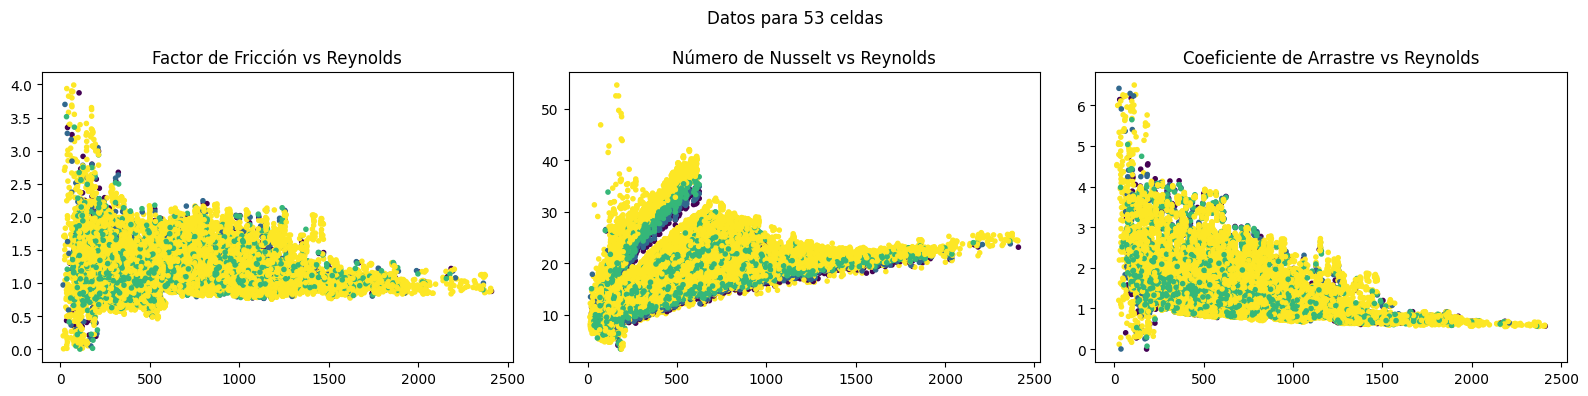

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ff_25['Rem'], ff_25['frictionFactor'], marker='.', c=ff_25['SoH'])
axes[0].set_title('Factor de Fricción vs Reynolds')

axes[1].scatter(nu_25['Rem'], nu_25['nusselt'], marker='.', c=nu_25['SoH'])
axes[1].set_title('Número de Nusselt vs Reynolds')

axes[2].scatter(cdrag_25['Rem'], cdrag_25['cdrag'], marker='.', c=cdrag_25['SoH'])
axes[2].set_title('Coeficiente de Arrastre vs Reynolds')

fig.suptitle('Datos para 25 celdas')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ff_53['Rem'], ff_53['frictionFactor'], marker='.', c=ff_53['SoH'])
axes[0].set_title('Factor de Fricción vs Reynolds')

axes[1].scatter(nu_53['Rem'], nu_53['nusselt'], marker='.', c=nu_53['SoH'])
axes[1].set_title('Número de Nusselt vs Reynolds')

axes[2].scatter(cdrag_53['Rem'], cdrag_53['cdrag'], marker='.', c=cdrag_53['SoH'])
axes[2].set_title('Coeficiente de Arrastre vs Reynolds')

fig.suptitle('Datos para 53 celdas')
plt.tight_layout()
plt.show()

In [14]:
database = {
    'nu': {
        25: nu_25,
        53: nu_53,
    },
    'ff': {
        25: ff_25,
        53: ff_53,
    },
    'cdrag': {
        25: cdrag_25,
        53: cdrag_53,
    },
}

with open('database_all_el7037.pkl', 'wb') as f:
    pickle.dump(database, f)

### Partición Aleatoria

In [294]:
cdrag_25_train, cdrag_25_other = train_test_split(cdrag_25, test_size=0.2, random_state=7)
cdrag_25_val, cdrag_25_test = train_test_split(cdrag_25_other, test_size=0.5, random_state=7)

cdrag_53_train, cdrag_53_other = train_test_split(cdrag_53, test_size=0.2, random_state=7)
cdrag_53_val, cdrag_53_test = train_test_split(cdrag_53_other, test_size=0.5, random_state=7)

cdrag_train = pd.concat([cdrag_25_train, cdrag_53_train], axis=0)
cdrag_train = shuffle(cdrag_train, random_state=7)

cdrag_val = pd.concat([cdrag_25_val, cdrag_53_val], axis=0)
cdrag_val = shuffle(cdrag_val, random_state=7)

cdrag_test = pd.concat([cdrag_25_test, cdrag_53_test], axis=0)
cdrag_test = shuffle(cdrag_test, random_state=7)

In [295]:
ff_25_train, ff_25_other = train_test_split(ff_25, test_size=0.2, random_state=7)
ff_25_val, ff_25_test = train_test_split(ff_25_other, test_size=0.5, random_state=7)

ff_53_train, ff_53_other = train_test_split(ff_53, test_size=0.2, random_state=7)
ff_53_val, ff_53_test = train_test_split(ff_53_other, test_size=0.5, random_state=7)

ff_train = pd.concat([ff_25_train, ff_53_train], axis=0)
ff_train = shuffle(ff_train, random_state=7)

ff_val = pd.concat([ff_25_val, ff_53_val], axis=0)
ff_val = shuffle(ff_val, random_state=7)

ff_test = pd.concat([ff_25_test, ff_53_test], axis=0)
ff_test = shuffle(ff_test, random_state=7)

In [296]:
nu_25_train, nu_25_other = train_test_split(nu_25, test_size=0.2, random_state=7)
nu_25_val, nu_25_test = train_test_split(nu_25_other, test_size=0.5, random_state=7)

nu_53_train, nu_53_other = train_test_split(nu_53, test_size=0.2, random_state=7)
nu_53_val, nu_53_test = train_test_split(nu_53_other, test_size=0.5, random_state=7)

nu_train = pd.concat([nu_25_train, nu_53_train], axis=0)
nu_train = shuffle(nu_train, random_state=7)

nu_val = pd.concat([nu_25_val, nu_53_val], axis=0)
nu_val = shuffle(nu_val, random_state=7)

nu_test = pd.concat([nu_25_test, nu_53_test], axis=0)
nu_test = shuffle(nu_test, random_state=7)

In [301]:
nu_train.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)
nu_test.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)
nu_val.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)

ff_train.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)
ff_test.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)
ff_val.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)

cdrag_train.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)
cdrag_test.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)
cdrag_val.rename({'separation': 'S', 'Rem': 'Re'}, inplace=True, axis=1)
print('')

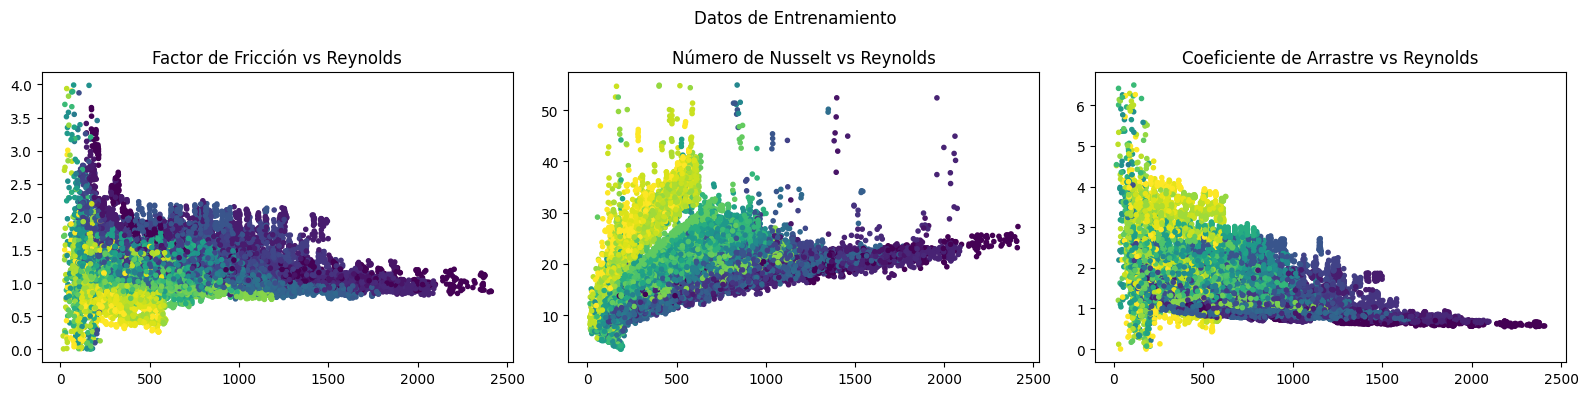

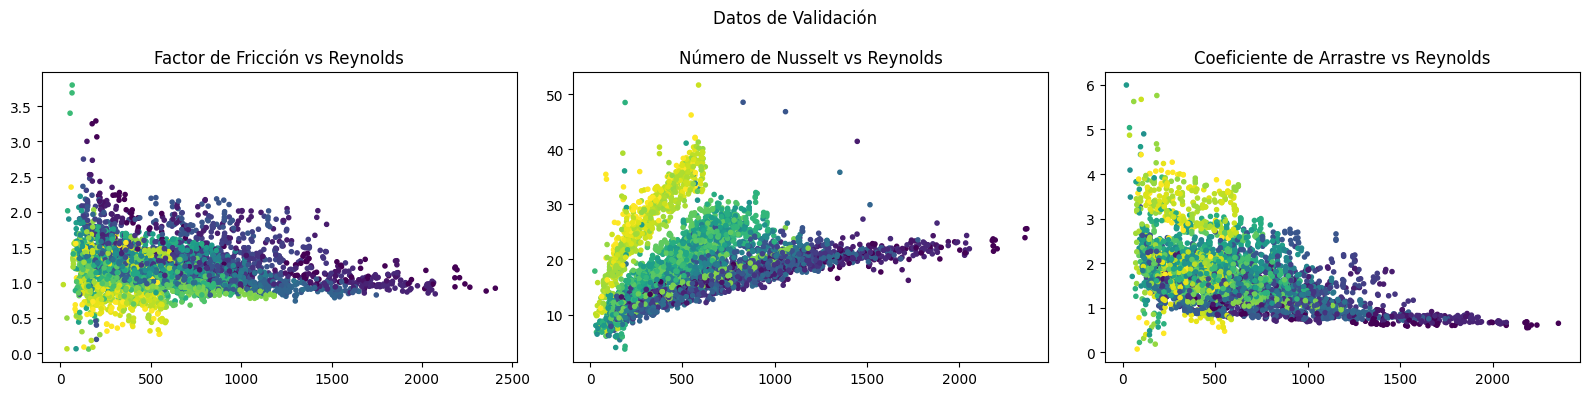

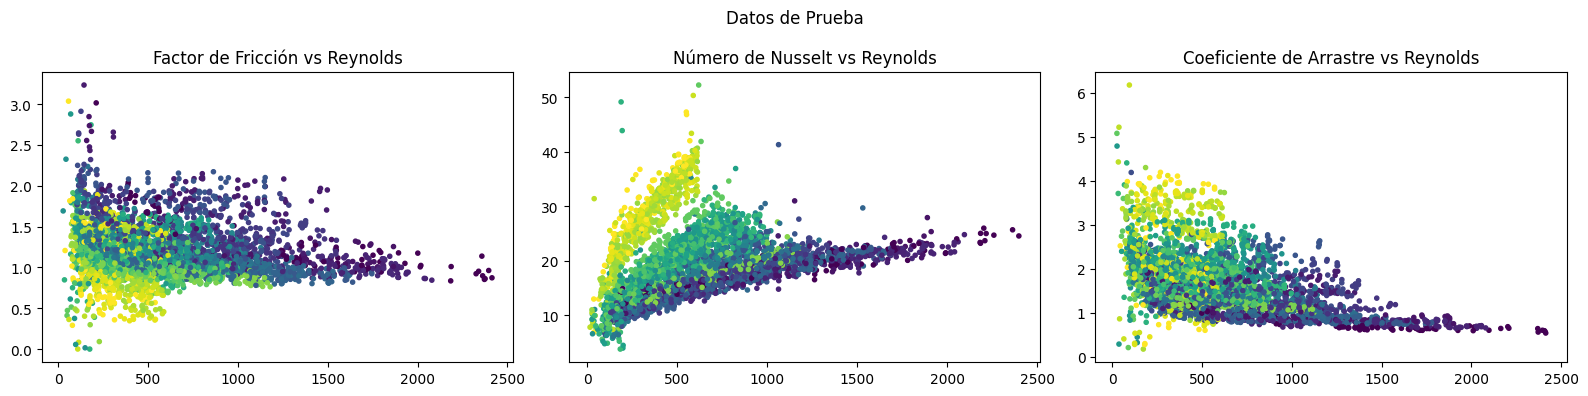

In [303]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ff_train['Re'], ff_train['frictionFactor'], marker='.', c=ff_train['S'])
axes[0].set_title('Factor de Fricción vs Reynolds')

axes[1].scatter(nu_train['Re'], nu_train['nusselt'], marker='.', c=nu_train['S'])
axes[1].set_title('Número de Nusselt vs Reynolds')

axes[2].scatter(cdrag_train['Re'], cdrag_train['cdrag'], marker='.', c=cdrag_train['S'])
axes[2].set_title('Coeficiente de Arrastre vs Reynolds')

fig.suptitle('Datos de Entrenamiento')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ff_val['Re'], ff_val['frictionFactor'], marker='.', c=ff_val['S'])
axes[0].set_title('Factor de Fricción vs Reynolds')

axes[1].scatter(nu_val['Re'], nu_val['nusselt'], marker='.', c=nu_val['S'])
axes[1].set_title('Número de Nusselt vs Reynolds')

axes[2].scatter(cdrag_val['Re'], cdrag_val['cdrag'], marker='.', c=cdrag_val['S'])
axes[2].set_title('Coeficiente de Arrastre vs Reynolds')

fig.suptitle('Datos de Validación')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ff_test['Re'], ff_test['frictionFactor'], marker='.', c=ff_test['S'])
axes[0].set_title('Factor de Fricción vs Reynolds')

axes[1].scatter(nu_test['Re'], nu_test['nusselt'], marker='.', c=nu_test['S'])
axes[1].set_title('Número de Nusselt vs Reynolds')

axes[2].scatter(cdrag_test['Re'], cdrag_test['cdrag'], marker='.', c=cdrag_test['S'])
axes[2].set_title('Coeficiente de Arrastre vs Reynolds')

fig.suptitle('Datos de Prueba')
plt.tight_layout()
plt.show()

In [304]:
database = {
    'nu': {
        'train': nu_train,
        'val': nu_val,
        'test': nu_test
    },
    'ff': {
        'train': ff_train,
        'val': ff_val,
        'test': ff_test
    },
    'cdrag': {
        'train': cdrag_train,
        'val': cdrag_val,
        'test': cdrag_test
    },
}

In [306]:
with open('database_random_el7037.pkl', 'wb') as f:
    pickle.dump(database, f)

In [310]:
with open('database_random_el7037.pkl', 'rb') as f:
    database = pickle.load(f)

database['nu']['train'].columns

Index(['dx', 'dy', 'F_in', 'T_in', 'S', 'q2', 'q4', 'q6', 'Desgaste', 'Re',
       'prandtl', 'colIndex', 'nusselt', 'n_cells', 'q8', 'q10', 'q12', 'q14',
       'SoH'],
      dtype='object')